# Hello World

In this Notebook, I will be taking my real first look at market data using `yfinance`, `pandas`, and `matplotlib`.

**Documentation References:**
1. `yfinance`: [GitHub](https://ranaroussi.github.io/yfinance/index.html)
2. `pandas`: [PyData](https://pandas.pydata.org/docs/)
3. `matplotlib`: [Matplotlib.org](https://matplotlib.org/stable/index.html)

To install yfinance, run the following code: `!pip install yfinance`

In [35]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

My essential libraries have been downloaded. Now we can:
1. Download stock data
2. View raw data
3. Plot closing prices

Let's begin with Step 1.

In [36]:
# We allow for a ticker input. If nothing was entered, the default is AAPL (Apple, Inc)
ticker = input("Enter the ticker: ")
if not ticker:
    ticker = "AAPL"

# We will download one year's worth of data and reference it with the data variable
data = yf.download(ticker, start="2024-01-01",end="2025-01-01")
print(data.columns)

Enter the ticker:  MSFT


[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


We can now view the raw data:

In [37]:
print(data.head(10)) # View the first ten rows
print("\nShape:", data.shape) # The number of rows and columns

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  364.589417  369.534234  360.558843  367.528772  25258600
2024-01-03  364.324005  366.938962  362.269402  362.760935  23083500
2024-01-04  361.709137  366.781759  360.952187  364.392917  20901500
2024-01-05  361.522278  365.759287  360.293446  362.721619  21004600
2024-01-08  368.344757  368.846130  362.760953  363.046020  23134000
2024-01-09  369.426117  369.622712  364.904011  365.710131  20830000
2024-01-10  376.287964  377.664280  369.947210  369.996351  25514200
2024-01-11  378.116455  384.063989  373.938427  379.463250  27850800
2024-01-12  381.891449  382.097884  378.136132  378.961903  21661200
2024-01-16  383.660919  387.357255  381.055802  386.993525  27202300

Shape: (252, 5)


Let's chart the closing prices:

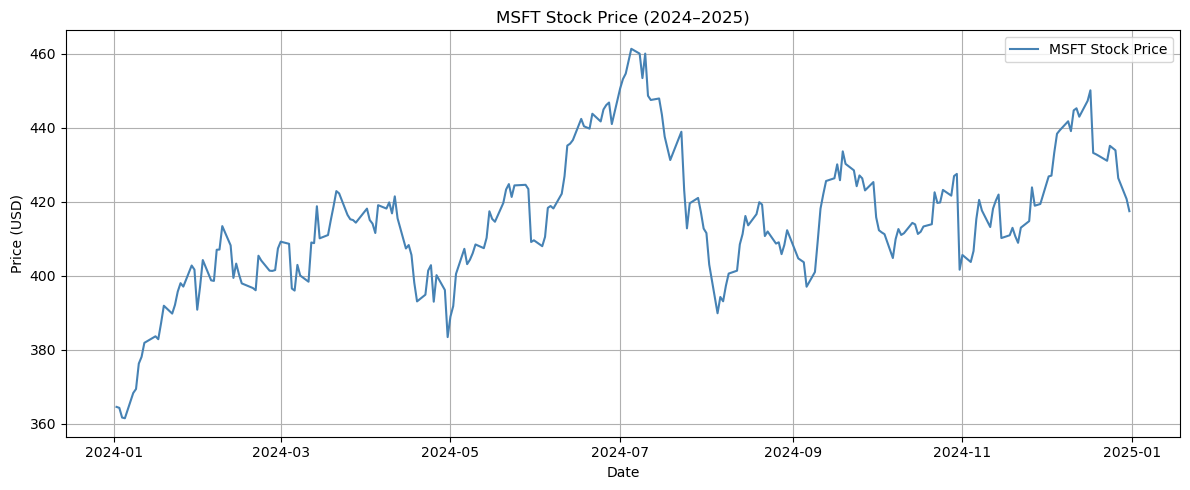

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(data["Close"], label=f"{ticker} Stock Price", color="steelblue")
plt.title(f"{ticker} Stock Price (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Returns and Statistics

Now we have prices, which means we can calculate the returns between each closing price point. The formula is:
$ r_t = \frac{P_t-P_{t-1}}{P_{t-1}}$
- $ r_t $: The return at time $t$. In this case, $t$ is one day
- $ P_t $: The price at day $t$
- $ P_{t-1} $: The price at the previous day

For example, if yesterday's closing price was `$100` and today's closing price is `$110`, the return is: 
$ r_t = \frac{110-100}{100} = 0.1 $

When converted to a percentage: $ 0.1 \times 100\% = 10\% $
We see a 10 percent return if we had bought the stock yesterday and sold it today.

Pandas does this automatically with the `.pct_change()` method:

In [39]:
# Create a new column "Returns" that is equal to the percent change in the closing stock prices
data["Returns"] = data["Close"].pct_change()
print(data["Returns"].head(10))

Date
2024-01-02         NaN
2024-01-03   -0.000728
2024-01-04   -0.007177
2024-01-05   -0.000517
2024-01-08    0.018872
2024-01-09    0.002936
2024-01-10    0.018574
2024-01-11    0.004859
2024-01-12    0.009984
2024-01-16    0.004633
Name: Returns, dtype: float64


Now let's explore the data using the pandas `.describe()` method:

In [40]:
print(data["Returns"].describe())

mean_return = data["Returns"].mean()
print(f"The mean return is: {mean_return:.2%}")

count    251.000000
mean       0.000619
std        0.012567
min       -0.060528
25%       -0.006056
50%        0.001154
75%        0.009165
max        0.026600
Name: Returns, dtype: float64
The mean return is: 0.06%


# Annualization

Before proceeding, we can run a sanity check:
- There are 252 trading days in a year. A count of 251 makes sense since it factors the return between each closing price entry

It's nice to have a summary of data, but most investors typically hold stock for longer than one day. A mean return of 0.06%\* per day may not be a useful metric. 

Let's annualize it:
$ 0.06\%\times 252 \approx 15.12\% $ annual return on average

We'll annualize volatility as well. Given a standard deviation of approximately 1.26\%\* per day:
$ 1.26\%\times\sqrt{252} \approx 20\% $ annual volatility
Let's analyze the min and max daily returns:
- Min: Approximately $ -6.05\%$

  $ \frac{-6.05\%}{1.26\%} = -4.8\sigma $; The min is 4.8 standard deviations* below the mean. That's a crazy outlier event!

  (According to the 68-95.99.7 rule, 99.7\% of values fall between 3 standard deviations of the mean. This data point lies outside that range.)
- Max: Approximately $ 2.66\% $

  $ \frac{2.66\%}{1.26\%} = 2.11\sigma $; The max is 2.11 standard deviations* above the mean.

\* *Figure was obtained using MSFT returns from 2024-01-01 to 2025-01-01*

In [41]:
# Calculate Mean, Std Dev
mean_return = data["Returns"].mean()
std_return = data["Returns"].std()
print(f"The mean of daily returns is: {mean_return:.2%}.\nThe volatility of daily returns is: {std_return:.2%}.")

The mean of daily returns is: 0.06%.
The volatility of daily returns is: 1.26%.


In [42]:
# Annualize
ann_mean_return = mean_return * 252
ann_std_return = std_return * (252**0.5)
print(f"The annualized mean return is: {ann_mean_return:.2%}.\nThe annualized volatility is: {ann_std_return:.2%}.")

The annualized mean return is: 15.60%.
The annualized volatility is: 19.95%.


# The Sharpe Ratio
*"A measure of an investment's risk-adjusted performance, calculated by comparing its return to that of a risk-free asset" - Investopedia*

In other words, the Sharpe Ratio measures excess return per unit of risk. The formula is: 
$Sharpe~Ratio = \frac{R_p-R_f}{\sigma_p}$
- $R_p$ Is the return on portfolio, but in this case our "portfolio" only contains one stock
- $R_f$ Is the risk-free rate. We will use 13-week (3 month) U.S. Treasury Bills to approximate this
- $\sigma_p$ Is the portfolio's volatility

The only way that the Sharpe Ratio can be negative is if the numerator is negative. In that case, our portfolio's return is less than the risk-free rate. A Sharpe Ratio of zero means that our portfolio's return matches the risk-free rate. Meanwhile, Sharpe Ratios greater than 0 indicate returns higher than the risk-free rate.

In [43]:
# Obtain 13-week (3 month) T-Bill data (^IRX)
tbill = yf.download("^IRX",start="2024-01-01",end="2025-01-01")
print(tbill.head(10))

[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open Volume
Ticker       ^IRX   ^IRX   ^IRX   ^IRX   ^IRX
Date                                         
2024-01-02  5.213  5.215  5.183  5.183      0
2024-01-03  5.235  5.235  5.230  5.235      0
2024-01-04  5.228  5.233  5.223  5.230      0
2024-01-05  5.220  5.233  5.215  5.228      0
2024-01-08  5.220  5.228  5.218  5.228      0
2024-01-09  5.230  5.235  5.228  5.230      0
2024-01-10  5.225  5.225  5.218  5.220      0
2024-01-11  5.218  5.228  5.203  5.218      0
2024-01-12  5.198  5.213  5.190  5.213      0
2024-01-16  5.203  5.215  5.203  5.208      0


In [44]:
# Quoted at an annual rate, so we need to convert it into daily units in order to calculate an accurate Sharpe Ratio
# .item() extracts the number from the pandas object. Note that IRX is stored in a multi-level column structure
rf_annual = tbill["Close"].mean().item() / 100
rf_daily = rf_annual / 252
print(f"The daily Risk-Free Rate is approximately: {rf_daily:.2%}")

# Calculate Daily Sharpe Ratio
sharpe = (mean_return - rf_daily) / std_return
# Annualize sharpe ratio
ann_sharpe = sharpe * (252 ** 0.5)

print(f"The Sharpe Ratio of {ticker} is {ann_sharpe:.2}")

The daily Risk-Free Rate is approximately: 0.02%
The Sharpe Ratio of MSFT is 0.53
